In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


# Cargar zonas urbanas de Santiago
comunas_rm = (
    gpd.read_file("datos/external/censo2017/R13/COMUNA_C17.shp")
    .to_crs("EPSG:4326")  # Asegurar WGS84 para el bounding box
)

# Extraer bounding box: [lon_min, lat_min, lon_max, lat_max]
minx, miny, maxx, maxy = comunas_rm.total_bounds
BOUNDS = [round(minx,3), round(miny,3), round(maxx,3), round(maxy,3)]

print(f"Bounding box comunas RM: {BOUNDS}")

Bounding box comunas RM: [np.float64(-71.715), np.float64(-34.291), np.float64(-69.77), np.float64(-32.922)]


## 2. Descarga del DEM (Copernicus GLO-30)

In [2]:
from dem_stitcher import stitch_dem
import numpy as np
import rasterio

# Bounding box: [lon_min, lat_min, lon_max, lat_max]
OUTPUT_FILE = "datos/external/nasadem/nasadem_santiago.tif"

print("Descargando DEM Copernicus 30m para Santiago...")
arr, profile = stitch_dem(
    BOUNDS,
    dem_name='glo_30',          # Copernicus GLO-30: global, sin login
    dst_ellipsoidal_height=False,
    dst_area_or_point='Point'
)

# Guardar como GeoTIFF
profile.update(dtype='float32', compress='lzw')
with rasterio.open(OUTPUT_FILE, 'w', **profile) as dst:
    dst.write(arr.astype('float32'), 1)

print(f"Archivo guardado: {OUTPUT_FILE}")

Descargando DEM Copernicus 30m para Santiago...


Reading tile imagery: 100%|██████████| 9/9 [00:07<00:00,  1.17it/s]


Archivo guardado: datos/external/nasadem/nasadem_santiago.tif


## 3. Verificar el archivo

In [3]:
import rasterio
import numpy as np

with rasterio.open(OUTPUT_FILE) as r:
    print("=== Info del raster ===")
    print(f"CRS        : {r.crs}")
    print(f"Resolución : ~{r.res[0]*111320:.0f} m")
    print(f"Dimensiones: {r.width} x {r.height} px")
    print(f"Bounds     : {r.bounds}")

    data = r.read(1).astype(float)
    if r.nodata:
        data[data == r.nodata] = np.nan

    print(f"\nElevación mínima : {np.nanmin(data):.0f} m")
    print(f"Elevación máxima : {np.nanmax(data):.0f} m")
    print(f"Elevación media  : {np.nanmean(data):.0f} m")

=== Info del raster ===
CRS        : EPSG:4326
Resolución : ~31 m
Dimensiones: 7003 x 4930 px
Bounds     : BoundingBox(left=-71.71513888888889, bottom=-34.291250000000005, right=-69.76986111111111, top=-32.92180555555556)

Elevación mínima : -9 m
Elevación máxima : 6573 m
Elevación media  : 1513 m


## 4. Visualización

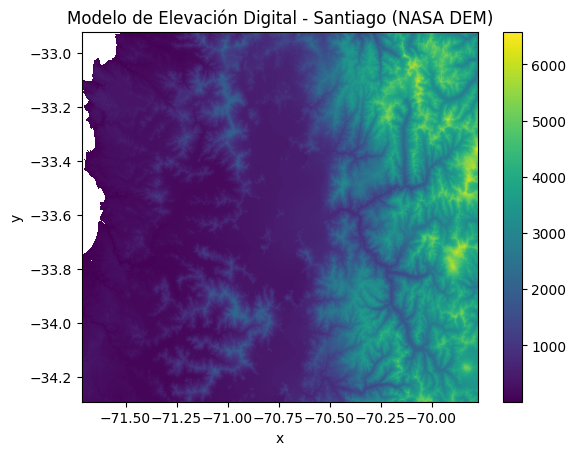

In [4]:
import rioxarray
import xarray
# Leer el Modelo de Elevación Digital (DEM)
dem = rioxarray.open_rasterio("datos/external/nasadem/nasadem_santiago.tif").sel(band=1)

# Visualizar la elevación (solo valores positivos = sobre el nivel del mar)
dem.where(dem > 0).plot.imshow()
plt.title("Modelo de Elevación Digital - Santiago (NASA DEM)", fontsize=12)
plt.show()

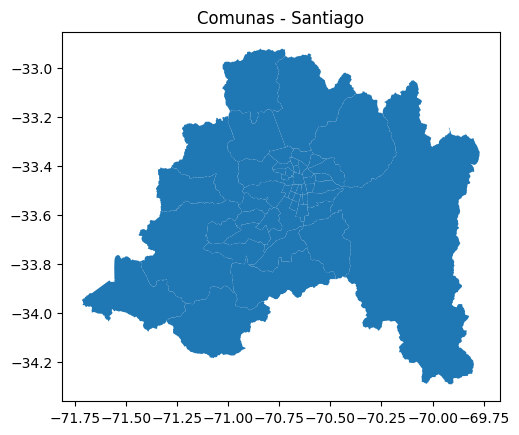


Número de comunas: 52


In [5]:
import geopandas as gpd
# Leer los tracts censales (barrios)
stgo_tracts = gpd.read_file("datos/external/censo2017/R13/COMUNA_C17.shp")

stgo_tracts.plot()
plt.title("Comunas - Santiago", fontsize=12)
plt.show()

print(f"\nNúmero de comunas: {len(stgo_tracts)}")

In [6]:
from rasterstats import zonal_stats

# Calcular estadísticas de elevación para TODOS los tracts
elevaciones = zonal_stats(
    stgo_tracts.to_crs(dem.rio.crs),       # Geometrías de los tracts (en CRS del DEM)
    "datos/external/nasadem/nasadem_santiago.tif",    # Ruta al archivo raster
)
elevaciones


[{'min': 320.5,
  'max': 2866.016357421875,
  'mean': 749.0032880822791,
  'count': 855818},
 {'min': 332.5,
  'max': 1722.0615234375,
  'mean': 496.5025790200817,
  'count': 274329},
 {'min': 450.34783935546875,
  'max': 1872.609375,
  'mean': 598.4690493290188,
  'count': 247846},
 {'min': 469.9914855957031,
  'max': 511.85467529296875,
  'mean': 488.70756880733944,
  'count': 13952},
 {'min': 484.29296875,
  'max': 3752.4970703125,
  'mean': 1290.9609464633047,
  'count': 1215895},
 {'min': 503.205078125,
  'max': 2217.458251953125,
  'mean': 892.8034084468505,
  'count': 818672},
 {'min': 461.9914855957031,
  'max': 2189.093994140625,
  'mean': 728.2312666143627,
  'count': 564647},
 {'min': 490.99725341796875,
  'max': 1630.0675048828125,
  'mean': 704.9009168780038,
  'count': 56387},
 {'min': 492.24627685546875,
  'max': 523.7100830078125,
  'mean': 506.48631314940883,
  'count': 13955},
 {'min': 125.0,
  'max': 1168.1790771484375,
  'mean': 298.7242312204917,
  'count': 496046}

In [7]:
# Convertir a DataFrame
elevaciones_df = pd.DataFrame(elevaciones)

print("Estadísticas zonales calculadas:")
elevaciones_df

Estadísticas zonales calculadas:


,min,max,mean,count
0,320.500000,2866.016357,749.003288,855818
1,332.500000,1722.061523,496.502579,274329
2,450.347839,1872.609375,598.469049,247846
3,469.991486,511.854675,488.707569,13952
4,484.292969,3752.497070,1290.960946,1215895
5,503.205078,2217.458252,892.803408,818672
6,461.991486,2189.093994,728.231267,564647
7,490.997253,1630.067505,704.900917,56387
8,492.246277,523.710083,506.486313,13955
9,125.000000,1168.179077,298.724231,496046


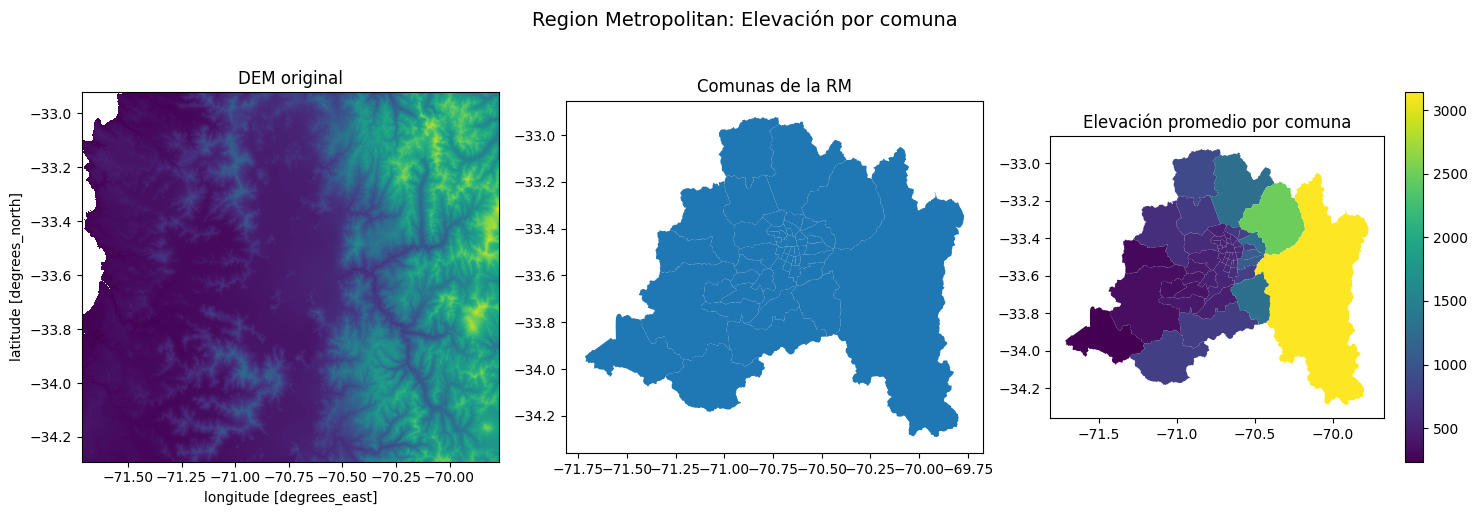

In [9]:
# Visualizar los resultados: elevación promedio por barrio
f, axs = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Superficie de elevación original
dem.where(dem > 0).rio.reproject(comunas_rm.crs).plot.imshow(
    ax=axs[0], add_colorbar=False
)
axs[0].set_title("DEM original")

# Panel 2: Tracts censales
comunas_rm.plot(ax=axs[1])
axs[1].set_title("Comunas de la RM")

# Panel 3: Elevación promedio por tract (coropleta)
comunas_rm.assign(elevacion=elevaciones_df["mean"]).plot(
    "elevacion", ax=axs[2], legend=True
)
axs[2].set_title("Elevación promedio por comuna")

plt.suptitle("Region Metropolitan: Elevación por comuna", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()